## Creating a Logistic Regression Model

### Discovery

Our task together today, is to explore energy sources and their impact on CARBON_INTENSITY. We will explore CARBON_INTENSITY levels, determine a threshold for HIGH_CARBON_INTENSITY and us logisitic regression to see if our energy sources can be used to predict whether we will hit HIGH_CARBON_INTENSITY thresholds or not. 

First we will import the required modules. They are:
- pandas
- seaborn
- statsmodels.api
- sklearn.model_selection - train_test_split
- sklearn.metrics - confusion_matrix
- matplotlib.pyplot

In [102]:
# Import required modules
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

--- 
### Data preparation
We are importing our data, exploring the row counts, columns and datatypes. Logistic regression requires continous, discreet or binary input variables, all must be numeric. Continuous variables are preferable to give your model greater accuracy. 

In [103]:
# Import the first dataset and set the date as the index
df = pd.read_csv("df_fuel_ckan.csv", index_col = "DATETIME", parse_dates=True)
df.head()

,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,OTHER,SOLAR,...,IMPORTS_perc,BIOMASS_perc,OTHER_perc,SOLAR_perc,STORAGE_perc,GENERATION_perc,LOW_CARBON_perc,ZERO_CARBON_perc,RENEWABLE_perc,FOSSIL_perc
DATETIME,,,,,,,,,,,,,,,,,,,,,
2009-01-01 00:00:00,8367.0000000000,15037.0000000000,7099.0000000000,248.0000000000,62.0000000000,246.0000000000,2518.0000000000,0.0000000000,0.0000000000,0.0000000000,...,7.5000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,100.0000000000,22.8000000000,24.5000000000,1.7000000000,69.7000000000
2009-01-01 00:30:00,8495.0000000000,15095.0000000000,7088.0000000000,229.0000000000,57.0000000000,245.0000000000,2495.0000000000,0.0000000000,0.0000000000,0.0000000000,...,7.4000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,100.0000000000,22.6000000000,24.3000000000,1.6000000000,70.0000000000
2009-01-01 01:00:00,8471.0000000000,15088.0000000000,7074.0000000000,207.0000000000,52.0000000000,246.0000000000,2465.0000000000,0.0000000000,0.0000000000,0.0000000000,...,7.3000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,100.0000000000,22.6000000000,24.2000000000,1.5000000000,70.1000000000
2009-01-01 01:30:00,8318.0000000000,15035.0000000000,7064.0000000000,191.0000000000,48.0000000000,246.0000000000,2439.0000000000,0.0000000000,0.0000000000,0.0000000000,...,7.3000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,100.0000000000,22.6000000000,24.3000000000,1.5000000000,70.0000000000
2009-01-01 02:00:00,8295.0000000000,15005.0000000000,7052.0000000000,175.0000000000,44.0000000000,246.0000000000,2363.0000000000,0.0000000000,0.0000000000,0.0000000000,...,7.1000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,100.0000000000,22.7000000000,24.3000000000,1.4000000000,70.2000000000


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 305103 entries, 2009-01-01 00:00:00 to 2026-05-28 07:00:00
Data columns (total 33 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   GAS               305103 non-null  float64
 1   COAL              305103 non-null  float64
 2   NUCLEAR           305103 non-null  float64
 3   WIND              305103 non-null  float64
 4   WIND_EMB          305103 non-null  float64
 5   HYDRO             305103 non-null  float64
 6   IMPORTS           305103 non-null  float64
 7   BIOMASS           305103 non-null  float64
 8   OTHER             305103 non-null  float64
 9   SOLAR             305103 non-null  float64
 10  STORAGE           305103 non-null  float64
 11  GENERATION        305103 non-null  float64
 12  CARBON_INTENSITY  305103 non-null  float64
 13  LOW_CARBON        305103 non-null  float64
 14  ZERO_CARBON       305103 non-null  float64
 15  RENEWABLE         305103 non-null 

Restrict the dataset to only the required columns.

In [105]:
# Import the second dataset and set the date as the index
df = df[["GAS","COAL","NUCLEAR","WIND","HYDRO","SOLAR","BIOMASS","CARBON_INTENSITY"]]
df.head()

,GAS,COAL,NUCLEAR,WIND,HYDRO,SOLAR,BIOMASS,CARBON_INTENSITY
DATETIME,,,,,,,,
2009-01-01 00:00:00,8367.0000000000,15037.0000000000,7099.0000000000,248.0000000000,246.0000000000,0.0000000000,0.0000000000,524.0000000000
2009-01-01 00:30:00,8495.0000000000,15095.0000000000,7088.0000000000,229.0000000000,245.0000000000,0.0000000000,0.0000000000,526.0000000000
2009-01-01 01:00:00,8471.0000000000,15088.0000000000,7074.0000000000,207.0000000000,246.0000000000,0.0000000000,0.0000000000,527.0000000000
2009-01-01 01:30:00,8318.0000000000,15035.0000000000,7064.0000000000,191.0000000000,246.0000000000,0.0000000000,0.0000000000,527.0000000000
2009-01-01 02:00:00,8295.0000000000,15005.0000000000,7052.0000000000,175.0000000000,246.0000000000,0.0000000000,0.0000000000,528.0000000000


In [106]:
# Final check on data types, columns and row counts. 
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 305103 entries, 2009-01-01 00:00:00 to 2026-05-28 07:00:00
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   GAS               305103 non-null  float64
 1   COAL              305103 non-null  float64
 2   NUCLEAR           305103 non-null  float64
 3   WIND              305103 non-null  float64
 4   HYDRO             305103 non-null  float64
 5   SOLAR             305103 non-null  float64
 6   BIOMASS           305103 non-null  float64
 7   CARBON_INTENSITY  305103 non-null  float64
dtypes: float64(8)
memory usage: 20.9 MB


--- 
### Model planning
We can begin to explore our data by looking at the average values for our dependent (output) variable, which will help us to understand what the distribution of data may look like.

In [107]:
# Get the mean and median prices from the dataset and print them in a single line of code. 
mean_ci = df["CARBON_INTENSITY"].mean()
med_ci = df["CARBON_INTENSITY"].median()
print(f"The mean is {mean_ci} and the median is {med_ci}.")

The mean is 288.17269577814704 and the median is 252.0.


Next we want to create a histogram to understand the distribution of our output variable, to understand what high CARBON_INTENSITY might look like. Once we have this, we can create a binary field in our dataset, showing us whether we have hit the threshold or not. 

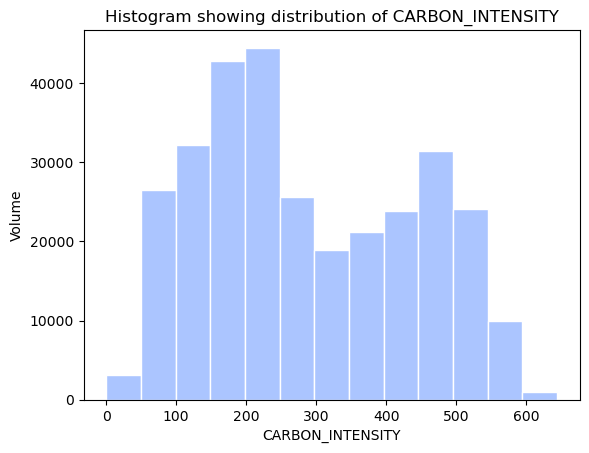

In [108]:
# Create a histogram to determine a suitable threshold for HIGH_CARBON_INTENSITY
hist = sns.histplot(x = "CARBON_INTENSITY",
             data = df,
             color="#8FB2FF",
             edgecolor="White",
             binrange=(0,df["CARBON_INTENSITY"].max()), # Binrange will start the bin at 0, not the first datapoint.
             binwidth = 50)
hist.set_ylabel("Volume")
hist.set_title("Histogram showing distribution of CARBON_INTENSITY")
plt.show()

In [109]:
# Create a new binary column in the dataframe which will be True/False based on the threshold. 
df["HIGH_CARBON_INTENSITY"] = df["CARBON_INTENSITY"] >= 350
df.head()

,GAS,COAL,NUCLEAR,WIND,HYDRO,SOLAR,BIOMASS,CARBON_INTENSITY,HIGH_CARBON_INTENSITY
DATETIME,,,,,,,,,
2009-01-01 00:00:00,8367.0000000000,15037.0000000000,7099.0000000000,248.0000000000,246.0000000000,0.0000000000,0.0000000000,524.0000000000,True
2009-01-01 00:30:00,8495.0000000000,15095.0000000000,7088.0000000000,229.0000000000,245.0000000000,0.0000000000,0.0000000000,526.0000000000,True
2009-01-01 01:00:00,8471.0000000000,15088.0000000000,7074.0000000000,207.0000000000,246.0000000000,0.0000000000,0.0000000000,527.0000000000,True
2009-01-01 01:30:00,8318.0000000000,15035.0000000000,7064.0000000000,191.0000000000,246.0000000000,0.0000000000,0.0000000000,527.0000000000,True
2009-01-01 02:00:00,8295.0000000000,15005.0000000000,7052.0000000000,175.0000000000,246.0000000000,0.0000000000,0.0000000000,528.0000000000,True


In [110]:
# Validate the binary value exists, with the bool datatype.
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 305103 entries, 2009-01-01 00:00:00 to 2026-05-28 07:00:00
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   GAS                    305103 non-null  float64
 1   COAL                   305103 non-null  float64
 2   NUCLEAR                305103 non-null  float64
 3   WIND                   305103 non-null  float64
 4   HYDRO                  305103 non-null  float64
 5   SOLAR                  305103 non-null  float64
 6   BIOMASS                305103 non-null  float64
 7   CARBON_INTENSITY       305103 non-null  float64
 8   HIGH_CARBON_INTENSITY  305103 non-null  bool   
dtypes: bool(1), float64(8)
memory usage: 21.2 MB


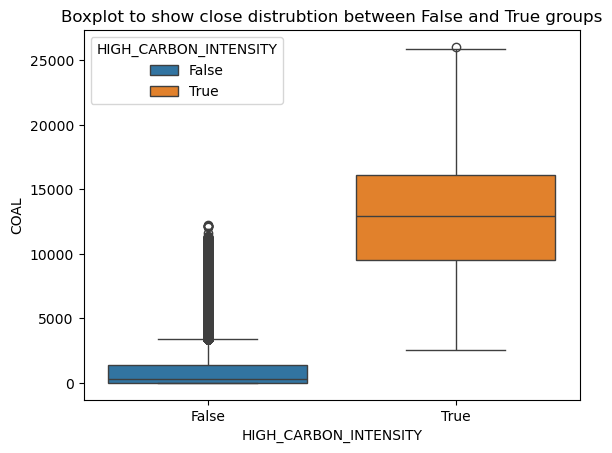

In [111]:
# Create a box plot to show the differences in distribution between your true and false groups. 
box = sns.boxplot(x = "HIGH_CARBON_INTENSITY",
                  y = "COAL",
                  data = df,
                  hue = "HIGH_CARBON_INTENSITY")

# Set title
box.set_title("Boxplot to show close distrubtion between False and True groups")
plt.show()

Finally, a correlation matrix will help us to see if there is a strong relationship between our dependent (output) variable and our binary independent (input) variable. It will also help us to check for intercorrelation. 

<Axes: >

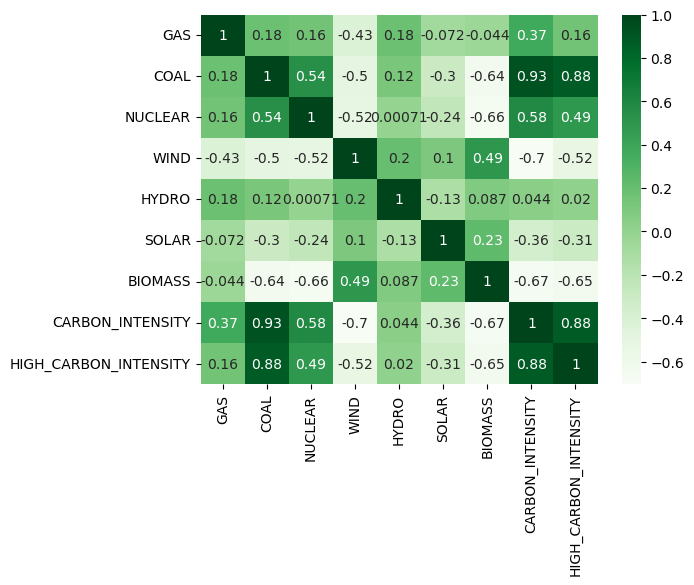

In [112]:
# Create a correlation matrix to demonstrate relationships between our variables. 
carbon_corr = df.corr()
sns.heatmap(carbon_corr, annot=True, cmap="Greens")

---
### Building the model

Building the data model is almost exactly the same as the process for Linear Regression. First, we split our data into training and test datasets. We set out dependent (output) variable, this time as our binary field. We then set our independent (input) variable, add the constant, and feed them both into the model function. This time, instead of using an OLS function, we will be using a Logit function. 

In [113]:
# Split the data into train and test samples
train, test = train_test_split(df,random_state=25)

Set both the independent variable and dependent variable - remember to check they are set correctly. Don't forget to add a constant to your independent variables. 

In [114]:
# Set the dependent variable and validate
dep = train["HIGH_CARBON_INTENSITY"]
dep.head()

DATETIME
2012-01-31 13:00:00     True
2015-03-16 11:00:00     True
2021-02-07 13:00:00    False
2009-05-15 23:00:00     True
2023-06-05 11:30:00    False
Name: HIGH_CARBON_INTENSITY, dtype: bool

In [115]:
# Set the independent variable and validate
ind = train[["COAL","WIND","SOLAR","BIOMASS"]]
ind.head()

,COAL,WIND,SOLAR,BIOMASS
DATETIME,,,,
2012-01-31 13:00:00,24527.0000000000,1113.0000000000,0.0000000000,0.0000000000
2015-03-16 11:00:00,16075.0000000000,697.0000000000,869.0000000000,0.0000000000
2021-02-07 13:00:00,316.0000000000,12858.0000000000,1583.0000000000,1631.0000000000
2009-05-15 23:00:00,7850.0000000000,680.0000000000,0.0000000000,0.0000000000
2023-06-05 11:30:00,0.0000000000,1387.0000000000,8100.0000000000,757.0000000000


In [116]:
# Remember to add the constant 
ind = sm.add_constant(ind)
ind.head()

,const,COAL,WIND,SOLAR,BIOMASS
DATETIME,,,,,
2012-01-31 13:00:00,1.0000000000,24527.0000000000,1113.0000000000,0.0000000000,0.0000000000
2015-03-16 11:00:00,1.0000000000,16075.0000000000,697.0000000000,869.0000000000,0.0000000000
2021-02-07 13:00:00,1.0000000000,316.0000000000,12858.0000000000,1583.0000000000,1631.0000000000
2009-05-15 23:00:00,1.0000000000,7850.0000000000,680.0000000000,0.0000000000,0.0000000000
2023-06-05 11:30:00,1.0000000000,0.0000000000,1387.0000000000,8100.0000000000,757.0000000000


Now generate the logistic regression model along with a summary output. 

In [117]:
# Fit the model and produce the summary
model = sm.Logit(dep,ind).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.035481
         Iterations 13


<class 'statsmodels.iolib.summary.Summary'>
"""
                             Logit Regression Results                            
=================================================================================
Dep. Variable:     HIGH_CARBON_INTENSITY   No. Observations:               228827
Model:                             Logit   Df Residuals:                   228822
Method:                              MLE   Df Model:                            4
Date:                   Fri, 05 Jun 2026   Pseudo R-squ.:                  0.9457
Time:                           16:34:45   Log-Likelihood:                -8118.9
converged:                          True   LL-Null:                   -1.4961e+05
Covariance Type:               nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.7140      0.106    -82.153      0.000      -8.922      -8.506
COAL           0.0023   2.57e-05     87.777      0.000       0.002       0.002
WIND          -0.0022   2.77e-05    -79.765      0.000      -0.002      -0.002
SOLAR         -0.0018   2.95e-05    -60.115      0.000      -0.002      -0.002
BIOMASS        0.0001   4.44e-05      3.032      0.002    4.77e-05       0.000
==============================================================================

Possibly complete quasi-separation: A fraction 0.81 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

--- 
### Communicating the results. 
You will now analyse the model and communicate the results. What do the following outputs tell you about the model

- Pseudo R-Squared: Best used to check the goodness of fit, when comparing models. Pseudo R-Squared does not account for variance. 
- P-Value: When below 0.05, we infer the independent variable is deemed to have a significant relationship with the dependent varaible. 
- Coefficient: In our case the independent variable coefficient is negative. This means as increase the independent variable, the log-odds, and therefore the likelihood of a positive outcome is reduced. 

In [118]:
# Use the model to predict which dates we are likely to hit high oil prices. Check the output. 
predictions = model.predict(ind) >= 0.5
predictions.head()

DATETIME
2012-01-31 13:00:00     True
2015-03-16 11:00:00     True
2021-02-07 13:00:00    False
2009-05-15 23:00:00     True
2023-06-05 11:30:00    False
dtype: bool

Once we have our preductions - we can use these to create a confusion matrix, which will help us to assess the model quality. 

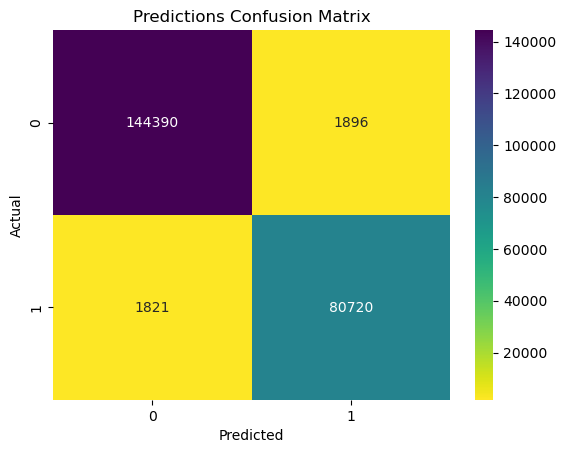

In [119]:
# Generate a confusion matrix to test the model.
conf_mat = confusion_matrix(dep, predictions)
conf_mat

# (Optional) Generate the confusion matrix as a heatmap
confusion_mat_heatmap = sns.heatmap(conf_mat, annot = True, cmap = 'viridis_r', fmt='g')

# (Optional) set x and y labels, and create a title
confusion_mat_heatmap.set_xlabel('Predicted')
confusion_mat_heatmap.set_ylabel('Actual')
confusion_mat_heatmap.set_title("Predictions Confusion Matrix")
plt.show()

**Basic Terminology**

**True Positives (TP)** is 80720: The model correctly predicted a large purchase. (Bottom right)

**True Negatives (TN)** is 144390: The model correctly predicted that it wont be a large purchase. (Top left)

**False Positives (FP)** is 1896: The model incorrectly predicted a large purchase. (Top right)

**False Negatives (FN)** is 1821: The model incorrectly predicted it wont be a large purchase. (Bottom left)

In [120]:
correct = 144390 + 80720 
incorrect = 1896 + 1821
all = (144390 + 80720 + 1896 + 1821)
print(correct)
print(incorrect)
print(all)
print(correct / all * 100)

225110
3717
228827
98.3756287501038


The model was correct in = 225110 cases; 

The model was incorrect in 3717 cases. 

Total = 228827 cases

That's a great overall success rate!<br> 
225110/228827 * 100 = 98.38% accuracy

In [121]:
# Format floats to return values to a maximum of x decimal places 
pd.set_option('display.float_format', '{:.10f}'.format) 

# Check incorrectly predicted rows
output = model.predict(ind) >= 0.5 # Binary outputs
out2 = model.predict(ind) # Model prediction confidence outputs

# Concert outputs to dataframe columns for comparison
train["predicted"] = output
train['predicted_num'] = out2 

# Check model accurate (or inaccurate) predictions
inc_diff = train[train["HIGH_CARBON_INTENSITY"] != train["predicted"]]
inc_diff

,GAS,COAL,NUCLEAR,WIND,HYDRO,SOLAR,BIOMASS,CARBON_INTENSITY,HIGH_CARBON_INTENSITY,predicted,predicted_num
DATETIME,,,,,,,,,,,
2011-08-21 23:00:00,12779.0000000000,4470.0000000000,6241.0000000000,915.0000000000,111.0000000000,0.0000000000,0.0000000000,363.0000000000,True,False,0.3404210290
2015-12-10 22:00:00,9767.0000000000,7813.0000000000,8392.0000000000,3405.0000000000,872.0000000000,0.0000000000,0.0000000000,338.0000000000,False,True,0.7971861370
2014-10-05 22:00:00,4745.0000000000,6711.0000000000,6014.0000000000,3598.0000000000,186.0000000000,0.0000000000,0.0000000000,352.0000000000,True,False,0.1762669027
2009-08-02 16:30:00,16777.0000000000,4441.0000000000,7583.0000000000,273.0000000000,371.0000000000,0.0000000000,0.0000000000,339.0000000000,False,True,0.6665416936
2010-08-18 23:00:00,14649.0000000000,3715.0000000000,6108.0000000000,143.0000000000,122.0000000000,0.0000000000,0.0000000000,350.0000000000,True,False,0.3415406256
...,...,...,...,...,...,...,...,...,...,...,...
2016-11-04 10:30:00,21200.0000000000,5956.0000000000,8123.0000000000,1835.0000000000,191.0000000000,1670.0000000000,0.0000000000,352.0000000000,True,False,0.0901024493
2014-10-18 00:30:00,5699.0000000000,6777.0000000000,4337.0000000000,4799.0000000000,149.0000000000,0.0000000000,0.0000000000,368.0000000000,True,False,0.0171523232
2010-06-10 02:00:00,14233.0000000000,3502.0000000000,5375.0000000000,603.0000000000,25.0000000000,0.0000000000,0.0000000000,353.0000000000,True,False,0.1040007914


In [122]:
# Test the model 
dep_test = test["HIGH_CARBON_INTENSITY"]
ind_test = test[["COAL","WIND","SOLAR","BIOMASS"]]
ind_test = sm.add_constant(ind_test)

# Produce the output and save to a dataframe column - then validate
output = model.predict(ind_test) >= 0.5
y_score = model.predict(ind_test)
test["predicted"] = output

# (Optional) Create a dataframe where only incorrect predictions are displayed
test = test[["HIGH_CARBON_INTENSITY","predicted","COAL","WIND","SOLAR","BIOMASS"]]
inc_diff = test[test["HIGH_CARBON_INTENSITY"] != test["predicted"]]
inc_diff

,HIGH_CARBON_INTENSITY,predicted,COAL,WIND,SOLAR,BIOMASS
DATETIME,,,,,,
2016-09-19 15:00:00,True,False,5494.0000000000,540.0000000000,1504.0000000000,0.0000000000
2018-03-09 14:00:00,True,False,6340.0000000000,1870.0000000000,1704.0000000000,1366.0000000000
2012-09-24 23:30:00,False,True,7807.0000000000,3551.0000000000,0.0000000000,0.0000000000
2012-01-02 05:30:00,False,True,6325.0000000000,2500.0000000000,0.0000000000,0.0000000000
2015-07-04 20:00:00,False,True,6509.0000000000,2431.0000000000,12.0000000000,0.0000000000
...,...,...,...,...,...,...
2017-01-12 11:30:00,True,False,8097.0000000000,4926.0000000000,590.0000000000,0.0000000000
2015-08-13 00:30:00,False,True,5348.0000000000,1467.0000000000,0.0000000000,0.0000000000
2010-08-24 05:00:00,True,False,3883.0000000000,760.0000000000,0.0000000000,0.0000000000


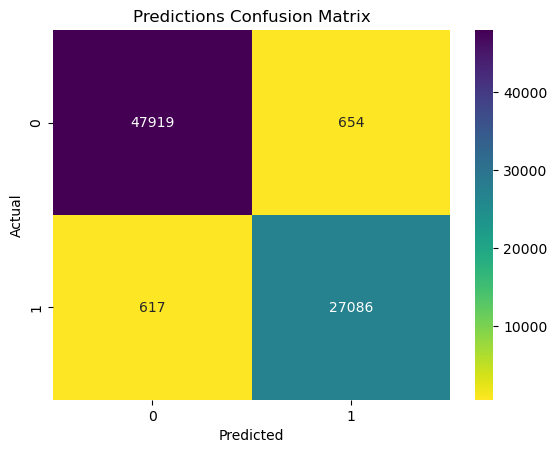

In [123]:
# Create a confusion matrix to display test results
tconf_mat = confusion_matrix(dep_test,output)
tconf_mat

# (Optional) Replicate the results as a heatmap as before:
tconfusion_mat_heatmap = sns.heatmap(tconf_mat, annot = True, cmap = 'viridis_r', fmt='g')

# (Optional) set x and y labels, and create a title
tconfusion_mat_heatmap.set_xlabel('Predicted')
tconfusion_mat_heatmap.set_ylabel('Actual')
tconfusion_mat_heatmap.set_title("Predictions Confusion Matrix")
plt.show()

--- 
### Operationalise
In the real world, this is where you would draft a report, deliver briefings, implement with automation on production level servers, produce technical documentation and build this into your BAU process.

--- 
### Stretch Tasks

By this stage, you have done everything required for CPD, but you can go further in your exploration of data, and analysis of the model. In this section we will:
- Produce a table of aggregates to look at the mean values for our data 
- Create a histogram with the continuous probability density curve
- Create a catplot to compare variables impact on HIGH_CARBON_DENSITY, in one visual, but individual axis
- Create a Receiver Operating Characteristic (ROC) curve, which is used to plot the True Positives, against the False positives.


In [124]:
# Create aggregate table on the true/false column. Find the mean value. Variables should have distinct differences in the mean.
df.groupby("HIGH_CARBON_INTENSITY").mean()

,GAS,COAL,NUCLEAR,WIND,HYDRO,SOLAR,BIOMASS,CARBON_INTENSITY
HIGH_CARBON_INTENSITY,,,,,,,,
False,11285.5364237731,1134.3575559764,5676.0340143386,5645.6651424876,391.7865430901,1420.4024653724,1506.7221837329,189.6325907451
True,13122.2801331592,12999.2209462646,7242.6732974130,1423.3100576902,402.0634864482,169.9633086608,17.9005569464,462.3447715975


---


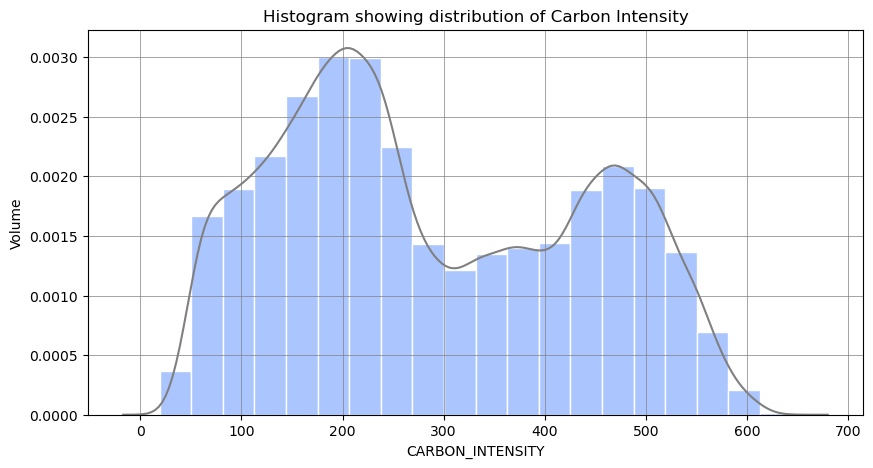

In [125]:
# Optional stylised output with a KDE... "...KDE represents the data using a continuous probability density curve in one or more dimensions".
# Fig represents the overall plot area, whereas ax represents everythinf cont
fig, ax = plt.subplots(figsize=(10,5))
plt.grid(visible = True, linestyle = "-",linewidth = 0.5, color = "grey")

sns.histplot(
    x="CARBON_INTENSITY",
    data=df,
    color="#8FB2FF",
    bins=20,
    edgecolor="White",
    stat="density",
    ax=ax
)

sns.kdeplot(
    x="CARBON_INTENSITY",
    data=df,
    color="grey",
    linewidth=1.5,
    ax=ax
)

ax.set_ylabel("Volume")
ax.set_title("Histogram showing distribution of Carbon Intensity")
plt.show()

---
Create a catplot to visualise relationships between input variables and HIGH_CARBON_INTENSITY on one diagram.

In [126]:
# Reformat the dataframe in preparation for multiple box plots
cidf_melted = df.melt(id_vars='HIGH_CARBON_INTENSITY', # target variable
                      value_vars=["GAS",
                                  "COAL",
                                  "NUCLEAR",
                                  "WIND",
                                  "HYDRO",
                                  "SOLAR",
                                  "BIOMASS"], # independent variables
                                  var_name='Variable', # independent variable column header
                                  value_name='Value' # independent variable value column header
                                  )
cidf_melted.head()

,HIGH_CARBON_INTENSITY,Variable,Value
0,True,GAS,8367.0000000000
1,True,GAS,8495.0000000000
2,True,GAS,8471.0000000000
3,True,GAS,8318.0000000000
4,True,GAS,8295.0000000000


C:\Users\CharlesArthur\AppData\Local\Temp\ipykernel_22764\402964855.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig1 = sns.catplot(x = 'HIGH_CARBON_INTENSITY', # Dependent variable


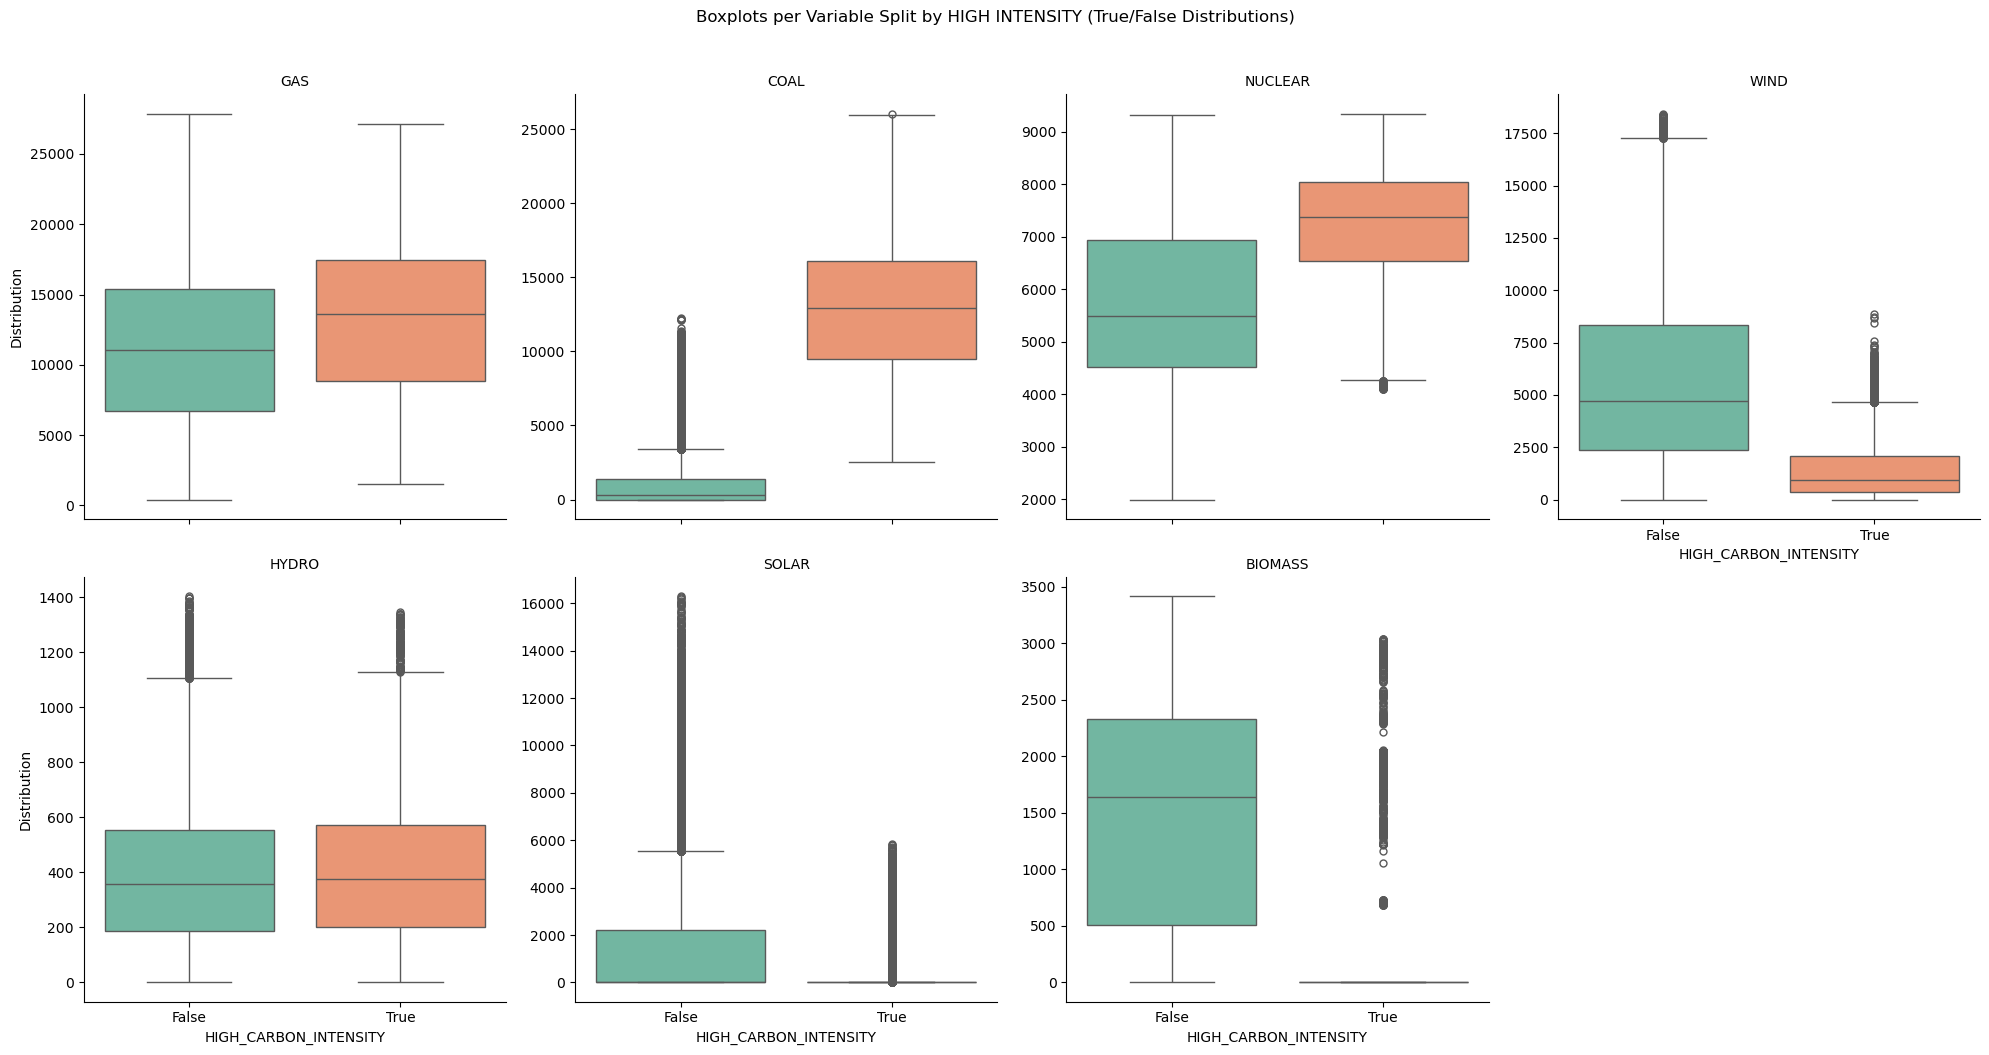

In [127]:
fig1 = sns.catplot(x = 'HIGH_CARBON_INTENSITY', # Dependent variable
            y = "Value", # Independent variable value
            col = "Variable", # Independent variable
            kind = 'box', # Set format to box plot
            data = cidf_melted, # Confirm the dataset
            col_wrap = 4, # Set to be 3 box plots across, adjust to your liking
            sharey = False, # Ensure y axis is not shared
            palette = 'Set2', # Colour palette is set, adjust to your liking
            )

fig1.set_titles("{col_name}") # Set individual box plot titles based on each Variable
fig1.set_axis_labels("HIGH_CARBON_INTENSITY", "Distribution") # Set x and Y axis titles
fig1.fig.suptitle("Boxplots per Variable Split by HIGH INTENSITY (True/False Distributions)", y=1.05) #y is the distance between title and visuals

plt.show() # Display the visualisation

---


In [128]:
from sklearn.metrics import roc_curve, auc

# Calculate the false positive rate (fpr), true positive rate (tpr) and thesholds whereby the model will predict a true positive.
fpr, tpr, thresholds = roc_curve(dep_test, y_score)


# Validate they have been calculated correctly
print(fpr)
print(tpr)
print(thresholds)

[0.         0.         0.         ... 0.97478023 0.9748214  1.        ]
[0.         0.05028336 0.06161788 ... 1.         1.         1.        ]
[           inf 1.00000000e+00 1.00000000e+00 ... 9.25034180e-20
 9.24904792e-20 3.12734232e-29]


In [129]:
# Calculate the area under curve (AUC) using the sklearn metric. 
roc_auc = auc(fpr, tpr)
print(f'The area under curve is calculated as {roc_auc}')

The area under curve is calculated as 0.9991622428121248


In [130]:
# Put the data into a dataframe, ready for visualisation. Then validate
roc_df = pd.DataFrame({
    "False Positive Rate": fpr,
    "True Positive Rate": tpr
})
roc_df.head()

,False Positive Rate,True Positive Rate
0,0.0000000000,0.0000000000
1,0.0000000000,0.0502833628
2,0.0000000000,0.0616178753
3,0.0000000000,0.0671046457
4,0.0000000000,0.0720860557


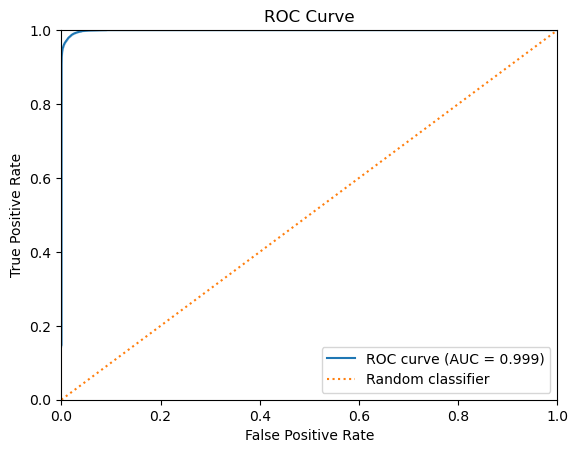

In [131]:
# Plot the ROC curve
sns.lineplot(x="False Positive Rate",
             y="True Positive Rate",
             
             data=roc_df,
             label=f"ROC curve (AUC = {roc_auc:.3f})")

# Diagonal baseline
sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle=":",
    label="Random classifier"
)

plt.title("ROC Curve")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()